# 00 · From computation to learning
### A visual laboratory for gradients, backpropagation, and optimization

**The question:** How can a collection of arithmetic operations change itself to fit examples?

We will follow one prediction through a graph, trace responsibility backward, check that
calculation numerically, and train a small neural network using only NumPy.
No training framework or downloaded dataset is required.

**Prerequisites:** Python functions, arrays, and elementary algebra. Derivatives and matrix
shapes are introduced as they become necessary. Allow roughly 60–90 minutes including experiments.

**Route:** prediction → loss → derivative → chain rule → backpropagation → optimization → generalization.

**How to use this lesson:** run from the top. At each **Predict** prompt, make a guess before
running the next cell. Change a suggested parameter, observe the result, then restore it or
restart and run all. Exercises appear before a separate solutions section.

From the repository root, install with `python -m pip install -r learn/vector_01/requirements.txt`.
Use that environment as your notebook kernel. This notebook runs from any working directory.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from IPython.display import display, Markdown

SEED = 42
np.set_printoptions(precision=5, suppress=True)
plt.rcParams.update({
    'figure.figsize': (10, 4), 'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'font.size': 10,
    'axes.grid': True, 'grid.alpha': 0.18,
})
BLUE, ORANGE, GREEN, RED = '#2563eb', '#d97706', '#15803d', '#dc2626'
print('NumPy', np.__version__)

NumPy 2.3.5


## 1 · A model is a function with adjustable numbers

An input $x$ is observed. A target $y$ is the desired answer. A prediction $\hat y$ is the
model's answer. Parameters, collected as $\theta$, are the numbers we adjust.

For a straight line, $\hat y=wx+b$: $w$ controls slope and $b$ controls vertical offset.
For $N$ examples we will use **half mean squared error**:

$$L(\theta)=\frac{1}{2N}\sum_{i=1}^{N}(\hat y_i-y_i)^2.$$

Squaring makes positive and negative errors contribute positively. Averaging prevents loss
from growing merely because we duplicate the dataset. The factor $1/2$ simplifies derivatives;
our displayed losses are half of conventional MSE.

**Predict:** which line should have lower loss? Does crossing one target guarantee a good fit overall?

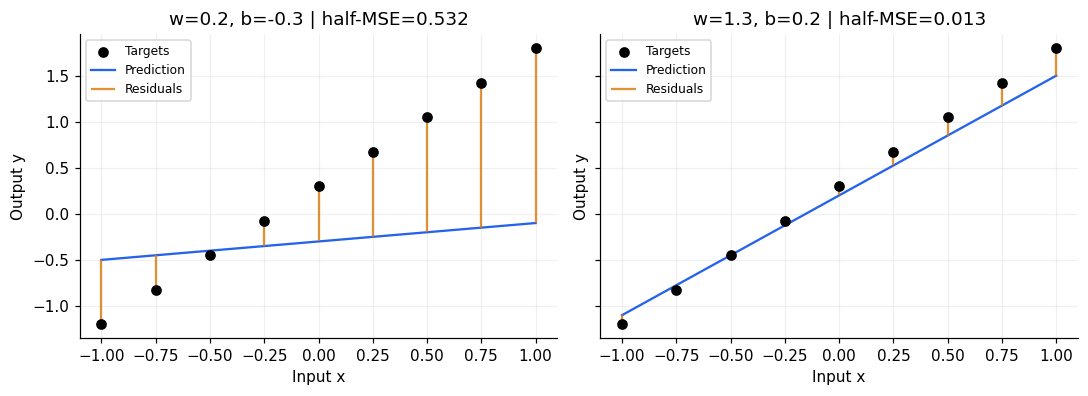

In [2]:
x_line = np.linspace(-1, 1, 9)
y_line = 1.5 * x_line + 0.3

def half_mse(prediction, target):
    return float(0.5 * np.mean((prediction - target) ** 2))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.7), sharey=True)
for ax, (w, b) in zip(axes, [(0.2, -0.3), (1.3, 0.2)]):
    prediction = w * x_line + b
    ax.scatter(x_line, y_line, color='black', label='Targets', zorder=3)
    ax.plot(x_line, prediction, color=BLUE, label='Prediction')
    ax.vlines(x_line, y_line, prediction, color=ORANGE, alpha=0.8, label='Residuals')
    ax.set(title=f'w={w}, b={b} | half-MSE={half_mse(prediction, y_line):.3f}',
           xlabel='Input x', ylabel='Output y')
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 2 · Follow one prediction through a computation graph

Now use one hidden neuron:

$$z=wx+b,\quad h=\tanh(z),\quad \hat y=vh+c,\quad e=\hat y-y,\quad L=\tfrac12 e^2.$$

$w,b$ define the hidden neuron's input. $h$ is its activation. $v,c$ map that activation to
the prediction. The hyperbolic tangent, $\tanh$, bends a linear input into an S-shaped curve.
Without a nonlinear activation, stacking affine layers would still produce an affine function.

The boxes below show **values flowing forward**, then the same nodes annotated with
**loss sensitivities flowing backward**. A sensitivity answers: if this intermediate value
increased a tiny amount, how much would the final loss change?

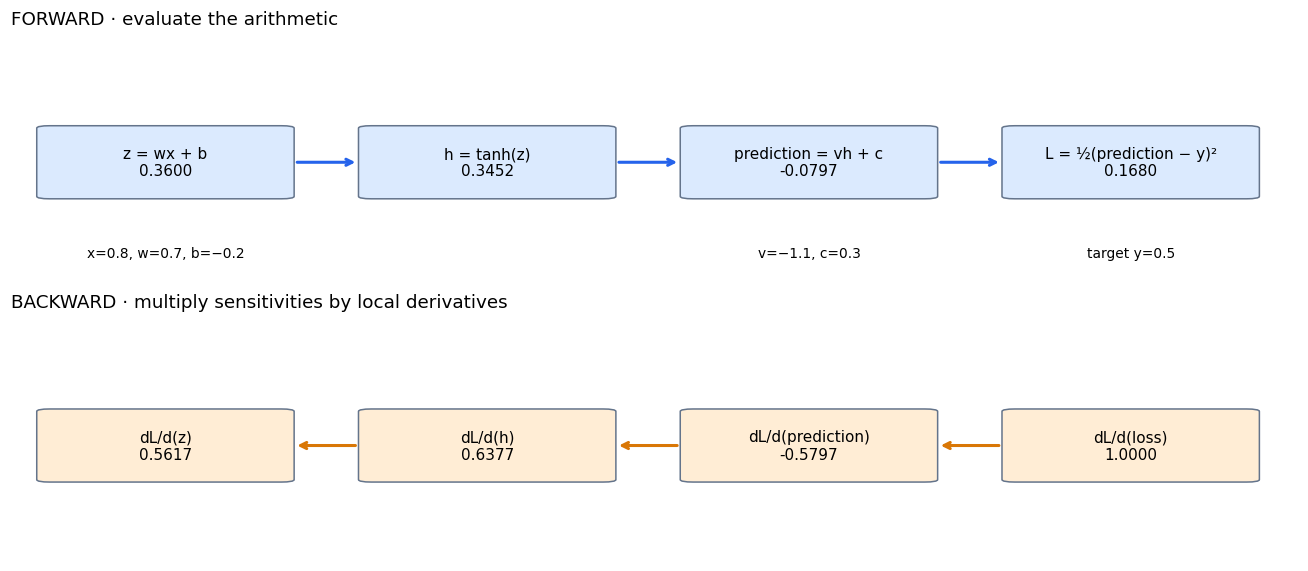

In [3]:
sample_x, sample_y = 0.8, 0.5
theta = dict(w=0.7, b=-0.2, v=-1.1, c=0.3)

def scalar_forward(p, x=sample_x, y=sample_y):
    z = p['w'] * x + p['b']
    h = np.tanh(z)
    prediction = p['v'] * h + p['c']
    error = prediction - y
    return dict(z=z, h=h, prediction=prediction, error=error, loss=0.5 * error**2)

values = scalar_forward(theta)
# Chain rule: dL/de=e, de/dprediction=1, dprediction/dh=v, dh/dz=1-h².
sensitivities = {
    'prediction': values['error'],
    'h': values['error'] * theta['v'],
    'z': values['error'] * theta['v'] * (1 - values['h']**2),
    'loss': 1.0,
}

def graph_box(ax, x, y, text, color):
    ax.add_patch(FancyBboxPatch((x-0.09, y-0.14), 0.18, 0.28,
        boxstyle='round,pad=0.01', facecolor=color, edgecolor='#64748b', linewidth=1))
    ax.text(x, y, text, ha='center', va='center', fontsize=10)

fig, axes = plt.subplots(2, 1, figsize=(12, 5.3))
positions = [0.12, 0.37, 0.62, 0.87]
labels = ['z = wx + b', 'h = tanh(z)', 'prediction = vh + c', 'L = ½(prediction − y)²']
keys = ['z', 'h', 'prediction', 'loss']
for row, ax in enumerate(axes):
    ax.set(xlim=(0, 1), ylim=(0, 1))
    ax.axis('off')
    for pos, label, key in zip(positions, labels, keys):
        value = values[key] if row == 0 else sensitivities[key]
        text = f'{label}\n{value:.4f}' if row == 0 else f'dL/d({key})\n{value:.4f}'
        graph_box(ax, pos, 0.47, text, '#dbeafe' if row == 0 else '#ffedd5')
    for left, right in zip(positions[:-1], positions[1:]):
        start, end = ((left+0.10, right-0.10) if row == 0 else (right-0.10, left+0.10))
        ax.annotate('', xy=(end, 0.47), xytext=(start, 0.47),
                    arrowprops=dict(arrowstyle='->', lw=2, color=BLUE if row == 0 else ORANGE))
    ax.set_title('FORWARD · evaluate the arithmetic' if row == 0 else
                 'BACKWARD · multiply sensitivities by local derivatives', loc='left')
axes[0].text(0.12, 0.08, 'x=0.8, w=0.7, b=−0.2', ha='center', fontsize=9)
axes[0].text(0.62, 0.08, 'v=−1.1, c=0.3', ha='center', fontsize=9)
axes[0].text(0.87, 0.08, 'target y=0.5', ha='center', fontsize=9)
fig.tight_layout()
plt.show()

## 3 · A derivative is a local slope

Hold every parameter except $w$ fixed. Then the entire graph becomes a one-variable loss function $L(w)$.
For a sufficiently small change $\Delta w$:

$$L(w+\Delta w)\approx L(w)+\frac{\partial L}{\partial w}\Delta w.$$

The partial-derivative symbol $\partial$ means we vary one quantity while holding the others fixed.
The tangent is a **local** approximation. A step that is too large may increase loss even when
its direction was initially downhill.

The chain rule multiplies the derivatives along the path from $w$ to $L$:

$$\frac{\partial L}{\partial w}
=\underbrace{(\hat y-y)}_{\partial L/\partial\hat y}
\underbrace{v}_{\partial\hat y/\partial h}
\underbrace{(1-h^2)}_{\partial h/\partial z}
\underbrace{x}_{\partial z/\partial w}.$$

**Predict:** the residual is negative and $v$ is negative. With positive $x$, is the gradient
with respect to $w$ positive or negative? Which way should $w$ move to lower loss?

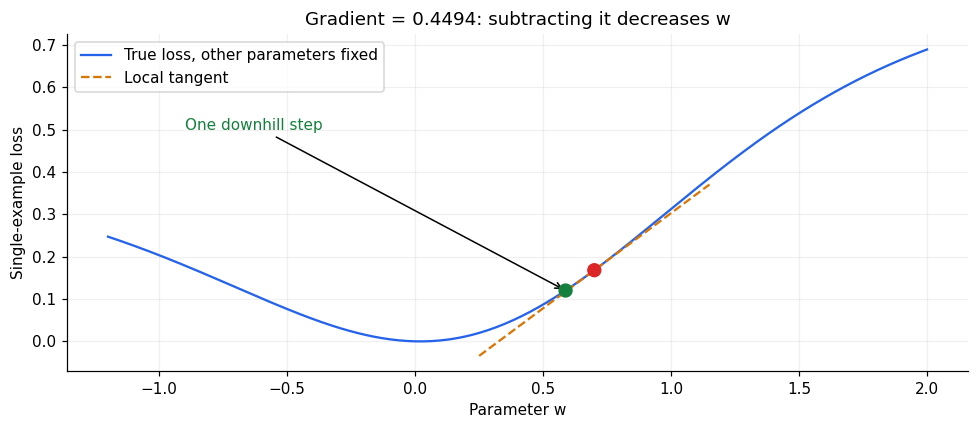

In [4]:
def scalar_gradients(p):
    q = scalar_forward(p)
    dz = q['error'] * p['v'] * (1 - q['h']**2)
    return dict(w=dz * sample_x, b=dz, v=q['error'] * q['h'], c=q['error'])

analytic = scalar_gradients(theta)
w_grid = np.linspace(-1.2, 2.0, 300)
loss_grid = [scalar_forward({**theta, 'w': w})['loss'] for w in w_grid]
w0, loss0 = theta['w'], values['loss']
local_w = np.linspace(w0-0.45, w0+0.45, 60)
step = 0.25
new_w = w0 - step * analytic['w']

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(w_grid, loss_grid, color=BLUE, label='True loss, other parameters fixed')
ax.plot(local_w, loss0 + analytic['w']*(local_w-w0), '--', color=ORANGE, label='Local tangent')
ax.scatter([w0, new_w], [loss0, scalar_forward({**theta, 'w': new_w})['loss']],
           c=[RED, GREEN], s=70, zorder=4)
ax.annotate('One downhill step', xy=(new_w, scalar_forward({**theta, 'w': new_w})['loss']),
            xytext=(-0.9, 0.5), arrowprops=dict(arrowstyle='->'), color=GREEN)
ax.set(xlabel='Parameter w', ylabel='Single-example loss',
       title=f'Gradient = {analytic["w"]:.4f}: subtracting it decreases w')
ax.legend()
fig.tight_layout()
plt.show()

## 4 · Backpropagation reuses intermediate derivatives

Instead of differentiating the whole expression separately for every parameter, compute
$\delta=\partial L/\partial z$ once and reuse it:

$$\delta=(\hat y-y)v(1-h^2),\qquad
\frac{\partial L}{\partial w}=\delta x,\quad
\frac{\partial L}{\partial b}=\delta,\quad
\frac{\partial L}{\partial v}=(\hat y-y)h,\quad
\frac{\partial L}{\partial c}=\hat y-y.$$

For a general graph, contributions from **every outgoing path are added**. If a parameter
is reused in two branches, both branches contribute to its gradient. With one scalar loss
and many parameters, this reverse traversal is especially efficient.

Gradient descent then updates all parameters together:
$\theta_{\text{new}}=\theta-\eta\nabla_\theta L$, where $\eta$ is the learning rate.
Backpropagation computes the gradient; the optimizer decides the update.

In [5]:
print('parameter  old value   gradient   new value')
updated = {name: value - 0.1*analytic[name] for name, value in theta.items()}
for name in theta:
    print(f'{name:>5} {theta[name]:12.5f} {analytic[name]:10.5f} {updated[name]:11.5f}')
print(f'Loss before: {scalar_forward(theta)["loss"]:.6f}')
print(f'Loss after:  {scalar_forward(updated)["loss"]:.6f}')
assert scalar_forward(updated)['loss'] < scalar_forward(theta)['loss']

# A shared parameter: u(w)=w*w + w. The product contributes w+w; the other branch adds 1.
shared_w = 2.0
print('Shared-parameter example, d(w*w + w)/dw at w=2:', shared_w + shared_w + 1)

parameter  old value   gradient   new value
    w      0.70000    0.44937     0.65506
    b     -0.20000    0.56171    -0.25617
    v     -1.10000   -0.20013    -1.07999
    c      0.30000   -0.57974     0.35797
Loss before: 0.168047
Loss after:  0.090145
Shared-parameter example, d(w*w + w)/dw at w=2: 5.0


## 5 · Check your calculus against small perturbations

A central finite difference estimates a derivative using two function evaluations:

$$g_{\text{numeric}}=\frac{L(\theta+\epsilon e_j)-L(\theta-\epsilon e_j)}{2\epsilon}.$$

$e_j$ changes only parameter $j$ by one unit, so $\epsilon e_j$ perturbs it by $\epsilon$.
Large $\epsilon$ gives approximation error; extremely small $\epsilon$ suffers floating-point
cancellation. Finite differences are useful checks but expensive training tools: roughly two
forward evaluations per parameter, compared with a reverse pass through the graph.

**Predict:** will making $\epsilon$ smaller always improve agreement?

w: hand= 0.44936917 numeric= 0.44936917
b: hand= 0.56171146 numeric= 0.56171146
v: hand=-0.20013281 numeric=-0.20013281
c: hand=-0.57973544 numeric=-0.57973544


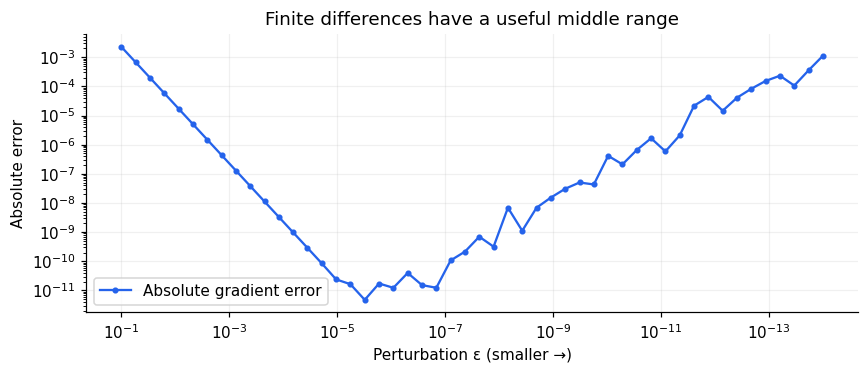

In [6]:
def scalar_finite_difference(p, name, eps=1e-6):
    plus, minus = dict(p), dict(p)
    plus[name] += eps
    minus[name] -= eps
    return (scalar_forward(plus)['loss'] - scalar_forward(minus)['loss']) / (2*eps)

for name in theta:
    numerical = scalar_finite_difference(theta, name)
    print(f'{name}: hand={analytic[name]: .8f} numeric={numerical: .8f}')
    np.testing.assert_allclose(analytic[name], numerical, rtol=1e-5, atol=1e-8)

epsilons = np.logspace(-1, -14, 50)
errors = [abs(scalar_finite_difference(theta, 'w', eps)-analytic['w']) for eps in epsilons]
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.loglog(epsilons, np.maximum(errors, 1e-18), color=BLUE, marker='.', label='Absolute gradient error')
ax.invert_xaxis()
ax.set(xlabel='Perturbation ε (smaller →)', ylabel='Absolute error',
       title='Finite differences have a useful middle range')
ax.legend()
fig.tight_layout()
plt.show()

## 6 · Visualize the optimizer in parameter space

An input-output plot shows what a model predicts. A **loss landscape** instead puts parameters
on its axes and shows how good their predictions are.

Return to the line $\hat y=wx+b$, fitted to $y=1.7x-0.4$. Every point in the contour plot below
is a different line. A training trajectory is a sequence of such points.

$$\frac{\partial L}{\partial w}=\operatorname{mean}((\hat y-y)x),\qquad
\frac{\partial L}{\partial b}=\operatorname{mean}(\hat y-y).$$

**Predict:** which learning rate will crawl, which will converge, and which will diverge?
This linear least-squares landscape is convex. The neural-network landscape later need not be.

Best [w, b]: [ 1.7 -0.4]
For this quadratic, stable positive step sizes are below: 0.914472057577732


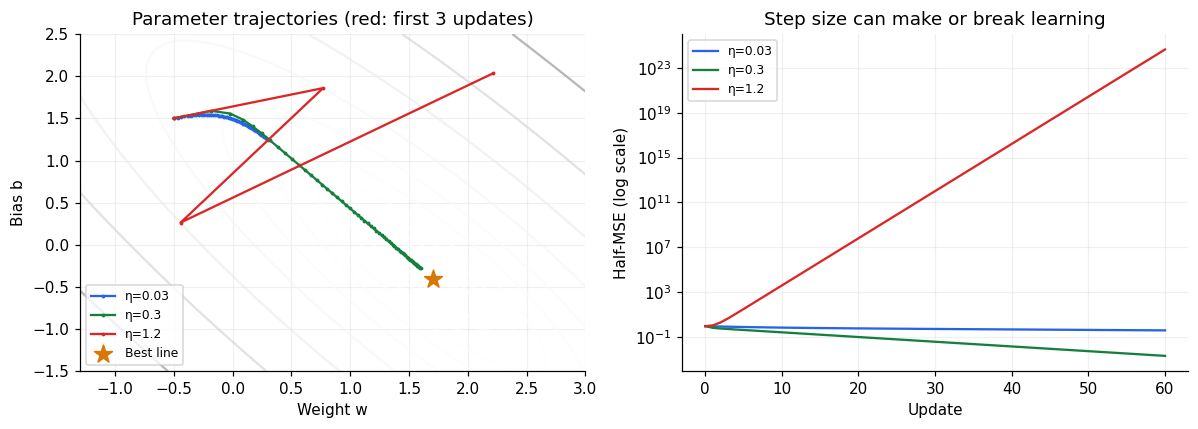

In [7]:
x_opt = np.linspace(0, 2, 60)
y_opt = 1.7*x_opt - 0.4
design = np.column_stack([x_opt, np.ones_like(x_opt)])
optimum = np.linalg.lstsq(design, y_opt, rcond=None)[0]

def line_descent(rate, steps=60):
    p = np.array([-0.5, 1.5])
    trajectory, losses = [p.copy()], [half_mse(design @ p, y_opt)]
    for _ in range(steps):
        residual = design @ p - y_opt
        gradient = design.T @ residual / len(y_opt)
        p = p - rate*gradient
        trajectory.append(p.copy())
        losses.append(half_mse(design @ p, y_opt))
    return np.array(trajectory), np.array(losses)

wg, bg = np.meshgrid(np.linspace(-1.3, 3, 100), np.linspace(-1.5, 2.5, 100))
surface = 0.5*np.mean((wg[..., None]*x_opt + bg[..., None] - y_opt)**2, axis=-1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].contour(wg, bg, surface, levels=np.geomspace(0.004, 12, 14), cmap='Greys', alpha=0.6)
for rate, color in [(0.03, BLUE), (0.3, GREEN), (1.2, RED)]:
    path, losses = line_descent(rate)
    visible_path = path[:4] if rate == 1.2 else path
    axes[0].plot(visible_path[:, 0], visible_path[:, 1], '.-', ms=3, color=color, label=f'η={rate}')
    axes[1].semilogy(losses, color=color, label=f'η={rate}')
axes[0].scatter(*optimum, marker='*', s=150, color=ORANGE, zorder=5, label='Best line')
axes[0].set(xlim=(-1.3, 3), ylim=(-1.5, 2.5), xlabel='Weight w', ylabel='Bias b',
            title='Parameter trajectories (red: first 3 updates)')
axes[1].set(xlabel='Update', ylabel='Half-MSE (log scale)', title='Step size can make or break learning')
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
print('Best [w, b]:', optimum)
print('For this quadratic, stable positive step sizes are below:',
      2/np.linalg.eigvalsh(design.T @ design / len(design)).max())

## 7 · Nonlinearity creates flexibility—and affects gradient flow

For $h=\tanh(z)$, the local derivative is $1-h^2$. Near zero it is close to one;
at large positive or negative $z$ it approaches zero. These flat regions are called
**saturation**. Multiplying by a small local derivative shrinks the backward signal.
Across many layers this can contribute to vanishing gradients.

A hidden layer learns several differently shifted and scaled curves. The output combines
them. This supplies a useful way to draw curved functions, but does not guarantee that
optimization finds a good combination or that the function extrapolates correctly.

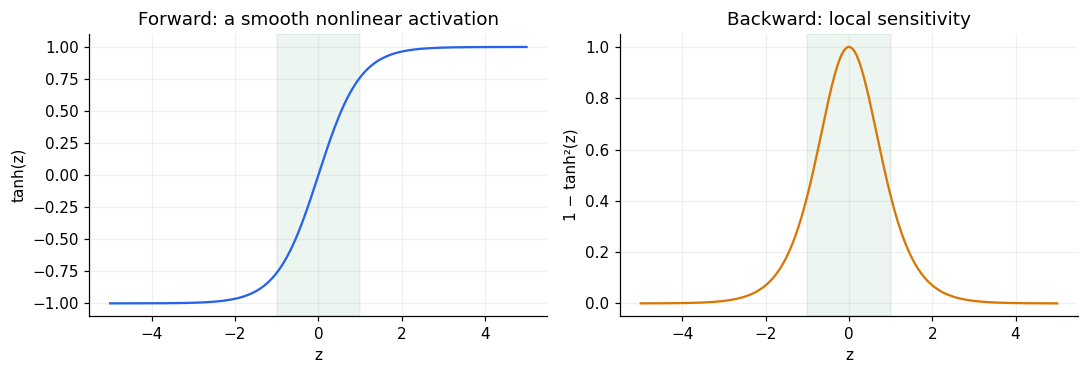

In [8]:
z_grid = np.linspace(-5, 5, 300)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(z_grid, np.tanh(z_grid), color=BLUE)
axes[1].plot(z_grid, 1-np.tanh(z_grid)**2, color=ORANGE)
axes[0].set(title='Forward: a smooth nonlinear activation', xlabel='z', ylabel='tanh(z)')
axes[1].set(title='Backward: local sensitivity', xlabel='z', ylabel='1 − tanh²(z)')
for ax in axes:
    ax.axvspan(-1, 1, color=GREEN, alpha=0.08)
fig.tight_layout()
plt.show()

## 8 · Scale the same graph to a batch and a hidden layer

A **batch** is a group of examples evaluated together. Each row below is one example.
Let $N$ be the batch size and $K$ the hidden width. This network has one input and one output:

$$Z=XW_1+b_1,\quad H=\tanh(Z),\quad \hat Y=HW_2+b_2.$$

| Quantity | Shape | Meaning |
|---|---|---|
| $X$, $Y$ | $N\times1$ | Inputs and targets |
| $W_1$ | $1\times K$ | Input weight for each hidden unit |
| $b_1$ | $1\times K$ | Hidden offsets, repeated across rows |
| $Z$, $H$ | $N\times K$ | Hidden values for each example |
| $W_2$ | $K\times1$ | Contribution of each hidden unit |
| $b_2$ | $1\times1$ | Output offset |
| $\hat Y$ | $N\times1$ | Predictions |

`@` means matrix multiplication: each output entry sums products across a matching dimension.
`*` means elementwise multiplication. NumPy **broadcasts** each bias across examples;
the reverse operation sums gradients across those examples.

Start the backward pass with $D=(\hat Y-Y)/N$. Then:

$$\nabla_{W_2}L=H^TD,\quad \nabla_{b_2}L=\sum_iD_i,$$
$$G=(DW_2^T)\odot(1-H^2),\quad
\nabla_{W_1}L=X^TG,\quad \nabla_{b_1}L=\sum_iG_i.$$

$\odot$ means elementwise multiplication. We divide by $N$ **once**, at the loss derivative.
These formulas assume a single output per example and the half-MSE defined earlier.
Random weights break symmetry between hidden units; all-zero weights would make hidden
units behave identically and, here, prevent their weights from learning.

In [9]:
def initialize(width=12, seed=SEED):
    rng = np.random.default_rng(seed)
    return {
        'W1': rng.normal(0, 0.7, (1, width)),
        'b1': np.zeros((1, width)),
        'W2': rng.normal(0, 1/np.sqrt(width), (width, 1)),
        'b2': np.zeros((1, 1)),
    }

def forward(p, X):
    Z = X @ p['W1'] + p['b1']
    H = np.tanh(Z)
    prediction = H @ p['W2'] + p['b2']
    return prediction, H

def loss_and_gradients(p, X, Y):
    assert X.ndim == 2 and X.shape[1] == 1
    assert Y.shape == (len(X), 1)
    prediction, H = forward(p, X)
    D = (prediction - Y) / len(X)
    G = (D @ p['W2'].T) * (1 - H**2)
    grads = {
        'W1': X.T @ G,
        'b1': G.sum(axis=0, keepdims=True),
        'W2': H.T @ D,
        'b2': D.sum(axis=0, keepdims=True),
    }
    return half_mse(prediction, Y), grads

example = initialize(width=3)
example_X = np.array([[-0.8], [0.2], [1.1]])
example_prediction, example_H = forward(example, example_X)
print('Input shape:', example_X.shape)
print('Hidden shape:', example_H.shape)
print('Output shape:', example_prediction.shape)
print('Parameter count:', sum(v.size for v in example.values()))

Input shape: (3, 1)
Hidden shape: (3, 3)
Output shape: (3, 1)
Parameter count: 10


### Check every parameter before trusting training

A loss can decrease even when some gradients are wrong. Numerical checks isolate the
backward calculation from the optimizer. We use a tiny network and nonzero biases so that
accidental symmetry is less likely to hide mistakes. The finite-difference forward loss
does not call the backward formulas.

W1: maximum absolute error 1.72e-11
b1: maximum absolute error 1.19e-11
W2: maximum absolute error 1.90e-11
b2: maximum absolute error 1.15e-11


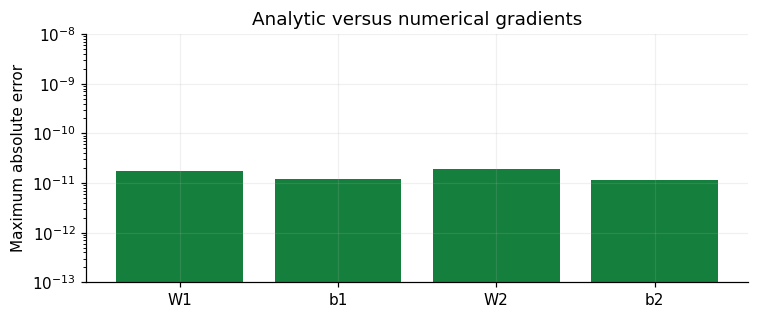

In [10]:
check_rng = np.random.default_rng(7)
check_p = initialize(width=3, seed=7)
check_p['b1'] = check_rng.normal(0, 0.2, check_p['b1'].shape)
check_p['b2'][:] = 0.17
check_X = check_rng.normal(size=(5, 1))
check_Y = check_rng.normal(size=(5, 1))
_, exact_grads = loss_and_gradients(check_p, check_X, check_Y)
max_errors = {}
epsilon = 1e-6
for name, array in check_p.items():
    numeric = np.zeros_like(array)
    for index in np.ndindex(array.shape):
        plus = {k: v.copy() for k, v in check_p.items()}
        minus = {k: v.copy() for k, v in check_p.items()}
        plus[name][index] += epsilon
        minus[name][index] -= epsilon
        numeric[index] = (half_mse(forward(plus, check_X)[0], check_Y)
                          - half_mse(forward(minus, check_X)[0], check_Y)) / (2*epsilon)
    np.testing.assert_allclose(exact_grads[name], numeric, rtol=1e-5, atol=1e-8)
    max_errors[name] = np.max(np.abs(exact_grads[name]-numeric))
    print(f'{name}: maximum absolute error {max_errors[name]:.2e}')
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(list(max_errors), np.maximum(list(max_errors.values()), 1e-16), color=GREEN)
ax.set(yscale='log', ylim=(1e-13, 1e-8), ylabel='Maximum absolute error', title='Analytic versus numerical gradients')
fig.tight_layout()
plt.show()

## 9 · Learn a curved function from examples

Generate noisy measurements of $f(x)=\sin(2x)+0.15x$ within $[-2,2]$. The model sees
training inputs and targets, not the formula. A separate validation set measures how
well it predicts fresh examples in the same range. The hidden width, seed, and number of
updates are fixed for this demonstration; we do not pick an epoch by looking at test data.

**Full-batch gradient descent** uses every training example per update. **Stochastic gradient
descent (SGD)** uses sampled examples or minibatches; that adds sampling noise. Our implementation
below is full-batch, including when we use Adam.

Adam keeps exponentially weighted averages of gradients $m_t$ and squared gradients $v_t$:

$$m_t=\beta_1m_{t-1}+(1-\beta_1)g_t,\quad
v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2.$$

They start at zero, so early averages are biased toward zero. Correct with
$\hat m_t=m_t/(1-\beta_1^t)$ and $\hat v_t=v_t/(1-\beta_2^t)$, then update elementwise:

$$\theta_t=\theta_{t-1}-\eta\frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}.$$

The first average smooths direction; the second changes step scale per parameter. Adam is
not guaranteed to beat gradient descent. Our comparison uses identical initial parameters
and update counts, but different learning rates; it illustrates behavior, not an optimizer benchmark.

In [11]:
def true_function(X):
    return np.sin(2*X) + 0.15*X

rng = np.random.default_rng(SEED)
X_train = np.sort(rng.uniform(-2, 2, 80))[:, None]
Y_train = true_function(X_train) + rng.normal(0, 0.05, X_train.shape)
X_valid = np.sort(rng.uniform(-2, 2, 80))[:, None]
Y_valid = true_function(X_valid) + rng.normal(0, 0.05, X_valid.shape)
X_plot = np.linspace(-2, 2, 300)[:, None]
initial = initialize()

def train(initial_parameters, optimizer='gd', rate=0.03, steps=1500):
    if optimizer not in {'gd', 'adam'}:
        raise ValueError("optimizer must be 'gd' or 'adam'")
    p = {k: v.copy() for k, v in initial_parameters.items()}
    m = {k: np.zeros_like(v) for k, v in p.items()}
    v = {k: np.zeros_like(value) for k, value in p.items()}
    beta1, beta2, eps = 0.9, 0.999, 1e-8
    history, snapshots = [], {}
    for t in range(steps + 1):
        loss, grads = loss_and_gradients(p, X_train, Y_train)
        valid_loss = half_mse(forward(p, X_valid)[0], Y_valid)
        history.append([loss, valid_loss])
        if t in {0, 50, 200, steps}:
            snapshots[t] = {k: value.copy() for k, value in p.items()}
        if t == steps:
            break
        # All gradients above come from the same parameter state.
        for name in p:
            g = grads[name]
            if optimizer == 'gd':
                p[name] -= rate*g
            else:
                m[name] = beta1*m[name] + (1-beta1)*g
                v[name] = beta2*v[name] + (1-beta2)*g**2
                m_hat = m[name] / (1-beta1**(t+1))
                v_hat = v[name] / (1-beta2**(t+1))
                p[name] -= rate*m_hat / (np.sqrt(v_hat)+eps)
    return p, np.array(history), snapshots

gd_p, gd_history, _ = train(initial, optimizer='gd', rate=0.03)
adam_p, adam_history, snapshots = train(initial, optimizer='adam', rate=0.01)
for name, history in [('Full-batch GD', gd_history), ('Adam', adam_history)]:
    assert np.isfinite(history).all()
    assert history[-1, 0] < history[0, 0]
    print(f'{name}: train {history[0, 0]:.5f} → {history[-1, 0]:.5f}; '
          f'validation {history[-1, 1]:.5f}')

Full-batch GD: train 0.24701 → 0.01254; validation 0.01509
Adam: train 0.24701 → 0.00090; validation 0.00146


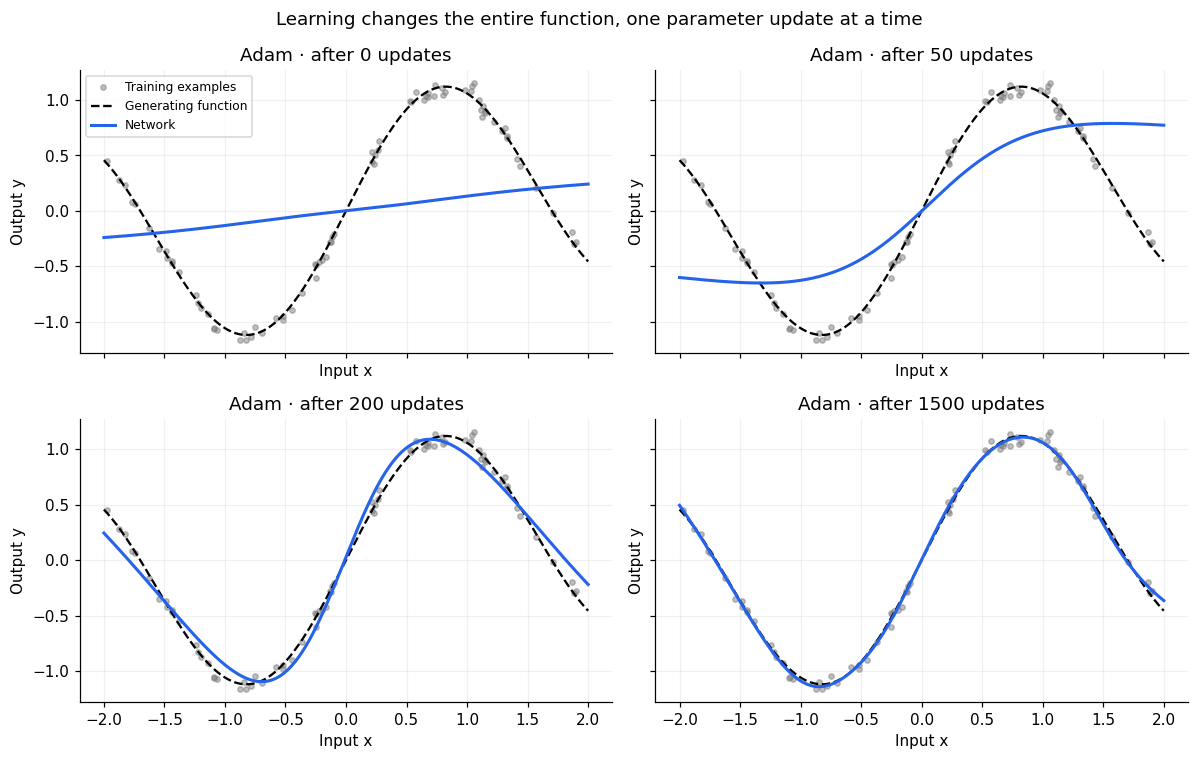

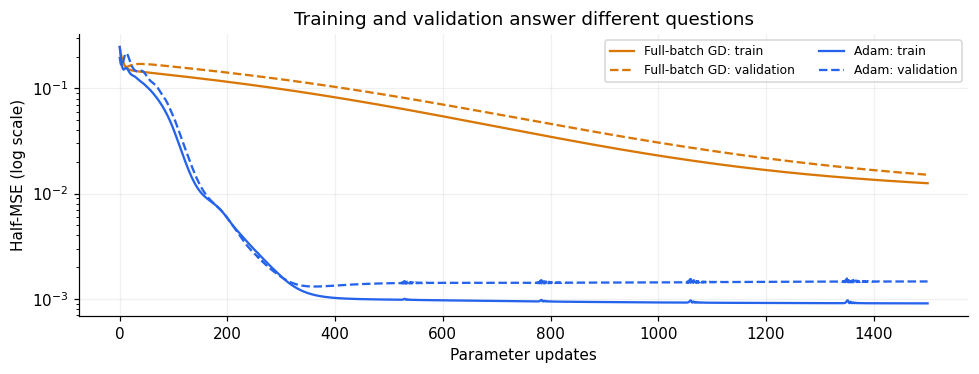

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)
for ax, (step, parameters) in zip(axes.flat, snapshots.items()):
    ax.scatter(X_train[:, 0], Y_train[:, 0], s=12, color='grey', alpha=0.5, label='Training examples')
    ax.plot(X_plot[:, 0], true_function(X_plot)[:, 0], '--', color='black', label='Generating function')
    ax.plot(X_plot[:, 0], forward(parameters, X_plot)[0][:, 0], color=BLUE, lw=2, label='Network')
    ax.set(title=f'Adam · after {step} updates', xlabel='Input x', ylabel='Output y')
axes[0, 0].legend(fontsize=8)
fig.suptitle('Learning changes the entire function, one parameter update at a time')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 3.5))
for history, color, name in [(gd_history, ORANGE, 'Full-batch GD'), (adam_history, BLUE, 'Adam')]:
    ax.semilogy(history[:, 0], color=color, label=f'{name}: train')
    ax.semilogy(history[:, 1], '--', color=color, label=f'{name}: validation')
ax.set(xlabel='Parameter updates', ylabel='Half-MSE (log scale)', title='Training and validation answer different questions')
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()

### Look inside the learned function

Each hidden unit produces a curve $h_j(x)$. Its contribution to the output is $W_{2,j}h_j(x)$.
Adding all these contributions and the output bias gives the prediction. The individual units
need not resemble a meaningful part of the generating formula; multiple units can cancel.

The heatmaps below show how their response to input changes during training. A large
network's representation is harder to inspect, but this same computation still applies.

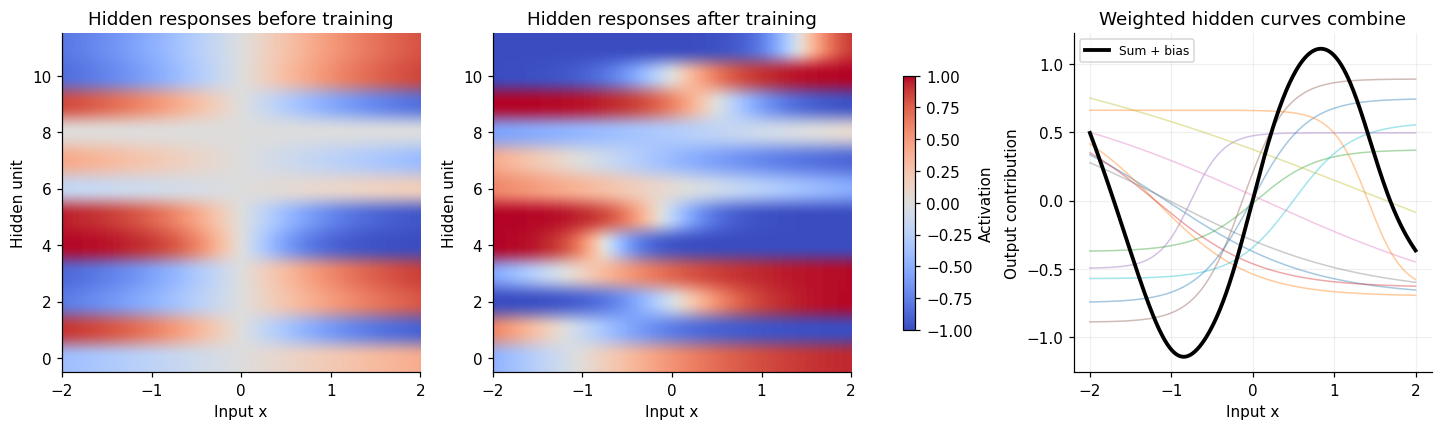

In [13]:
H_before = forward(initial, X_plot)[1]
prediction, H_after = forward(adam_p, X_plot)
contributions = H_after * adam_p['W2'].T
np.testing.assert_allclose(contributions.sum(axis=1, keepdims=True) + adam_p['b2'], prediction)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), layout='constrained')
for ax, H, title in zip(axes[:2], [H_before, H_after], ['Hidden responses before training', 'Hidden responses after training']):
    im = ax.imshow(H.T, aspect='auto', origin='lower', extent=(-2, 2, -0.5, H.shape[1]-0.5),
                   vmin=-1, vmax=1, cmap='coolwarm')
    ax.set(title=title, xlabel='Input x', ylabel='Hidden unit')
    ax.grid(False)
fig.colorbar(im, ax=axes[:2], shrink=0.75, label='Activation')
axes[2].plot(X_plot[:, 0], contributions, alpha=0.4, lw=1)
axes[2].plot(X_plot[:, 0], prediction[:, 0], color='black', lw=2.5, label='Sum + bias')
axes[2].set(title='Weighted hidden curves combine', xlabel='Input x', ylabel='Output contribution')
axes[2].legend(fontsize=8)
plt.show()

## 10 · Fitting is not the same as understanding a rule

Training changes parameters. **Inference** evaluates the forward graph with fixed parameters.
Neither a small training loss nor a smooth-looking curve proves that the model discovered the
formula that produced the data.

We now freeze the model and evaluate noiseless reference points inside and outside the training
range. These are a synthetic diagnostic: the reference formula is available because we made this
problem. In a real project, reserve a test set for final evaluation; use training and validation
for model decisions. Repeatedly tuning against a test set makes it part of model selection.

**Predict:** will the network continue the sine wave outside $[-2,2]$? Nothing in its loss
explicitly required that behavior. Each tanh unit eventually saturates, so this architecture
has bounded tails, whereas the generating function also has a growing linear term.

Within training range reference half-MSE: 0.00024
Outside training range reference half-MSE: 1.92003


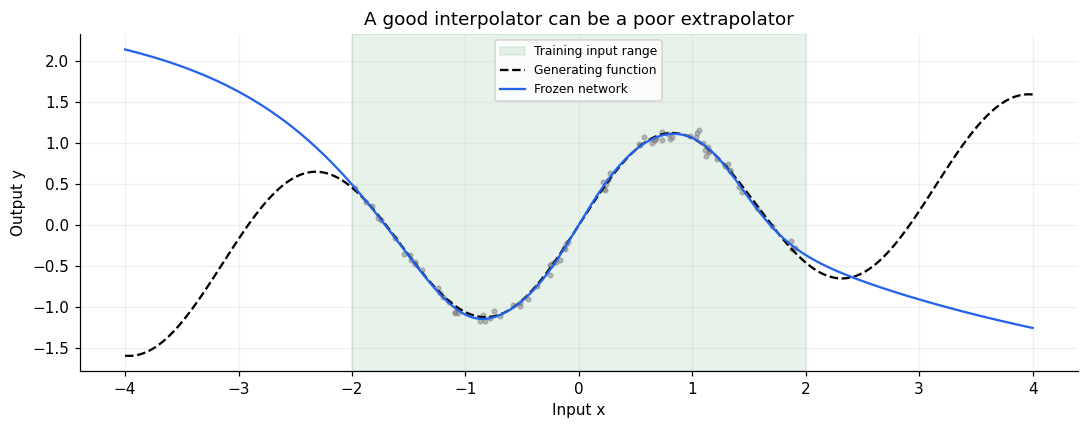

In [14]:
X_wide = np.linspace(-4, 4, 600)[:, None]
wide_prediction = forward(adam_p, X_wide)[0]
inside = np.abs(X_wide[:, 0]) <= 2
outside = ~inside
for label, mask in [('Within training range', inside), ('Outside training range', outside)]:
    print(label, 'reference half-MSE:', f'{half_mse(wide_prediction[mask], true_function(X_wide[mask])):.5f}')
fig, ax = plt.subplots(figsize=(10, 4))
ax.axvspan(-2, 2, color=GREEN, alpha=0.1, label='Training input range')
ax.plot(X_wide[:, 0], true_function(X_wide)[:, 0], '--', color='black', label='Generating function')
ax.plot(X_wide[:, 0], wide_prediction[:, 0], color=BLUE, label='Frozen network')
ax.scatter(X_train[:, 0], Y_train[:, 0], s=9, color='grey', alpha=0.5)
ax.set(xlabel='Input x', ylabel='Output y', title='A good interpolator can be a poor extrapolator')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 11 · Connect this foundation to the rest of the sequence

| Next concept | What carries over | What changes |
|---|---|---|
| Equation learner (01) | Differentiable graph, loss, backpropagation | Explicit mathematical operators and pressure toward simple expressions |
| Program hypotheses and search (02–04) | Candidate predictions, scoring, evaluation | Discrete structure usually cannot be optimized with ordinary backprop alone |
| Neural-guided search (05) | A network learns from examples | Predictions guide which symbolic candidates to explore |
| Structure embeddings (06) | Learned hidden representations | Inputs represent trees, graphs, or executions rather than single numbers |
| Abstractions and adaptation (07–08) | Reusable representations and honest evaluation | Learning reusable programs and testing new combinations |

A gradient tells you how to adjust numbers **within a chosen differentiable structure**.
It does not, by itself, choose the right program language, invent an abstraction, or prove
that a learned rule generalizes. Those are reasons to study the later lessons.

## 12 · Exercises: predict, change, explain

1. **Gradient sign.** Use the original scalar neuron. Compute the signs of all four parameter
   gradients before checking the table in section 4. Which parameters increase after one update?
2. **The missing average.** Suppose you remove `/ len(X)` from `D`. How does that change the
   gradient for our 80-example batch? What learning-rate change would exactly compensate for
   full-batch gradient descent? Would the same argument apply unchanged to Adam?
3. **Remove the nonlinearity.** In a copy of `forward`, replace `H = np.tanh(Z)` with `H = Z`.
   Also remove `(1-H**2)` in its matching backward function. Show algebraically why more hidden
   units cannot fit a sine curve exactly with this architecture. Do not change only the forward pass.
4. **Make saturation visible.** Plot `1-np.tanh(z)**2` at `z=0, 1, 3, 5`. Explain why a large
   activation magnitude can suppress a hidden weight's gradient even with a nonzero residual.
5. **Separate fit from generalization.** Repeat the experiment with widths 3 and 24, keeping
   the same data and optimizer settings. Compare training and validation loss. Form a hypothesis
   before viewing the wide-range diagnostic; do not choose the width using that diagnostic.

Stop here and try the exercises before reading the next cell.

## 13 · Solutions and reasoning

1. Here $e<0$, $v<0$, $x>0$, and $h>0$. Thus $\partial L/\partial w$ and
   $\partial L/\partial b$ are positive, whereas $\partial L/\partial v$ and
   $\partial L/\partial c$ are negative. Gradient descent decreases $w,b$ and increases $v,c$.
2. Removing the mean multiplies each gradient by 80. Dividing the GD learning rate by 80
   restores the exact update. Adam rescales by a running root-mean-square gradient: scaling all
   gradients by a positive constant largely cancels between numerator and denominator, except
   for the fixed epsilon term. Its compensation is not the same 80-fold learning-rate change.
3. With identity activations, $\hat Y=(XW_1+b_1)W_2+b_2
   =X(W_1W_2)+(b_1W_2+b_2)$. This is one affine function regardless of hidden width.
   The matrix products change the parameterization, not the family of functions.
4. The derivatives are approximately $1$, $0.4200$, $0.00987$, and $0.000182$.
   Backprop multiplies the incoming sensitivity by these numbers. A small local factor can
   substantially reduce the gradient; it does not imply the residual itself is small.
5. Results depend on width, initialization, and optimization. More parameters expand capacity
   but do not guarantee lower validation loss after a fixed number of updates or correct
   extrapolation. Report observed losses and curves rather than assuming the wider model wins.

## 14 · What you should be able to reconstruct

- Evaluate a small graph forward and name its parameters, intermediates, and loss.
- Apply the chain rule backward, including summing contributions when paths meet.
- Check a derivative using finite differences and explain why epsilon cannot be arbitrarily small.
- Explain the batch network's array shapes, bias gradient sums, and single averaging factor.
- Implement gradient descent and explain Adam's moving averages and bias correction.
- Distinguish optimization success, validation performance, and extrapolation.

**Terms:** a *parameter* is learned; a *hyperparameter* such as width or learning rate is chosen
outside the gradient update. An *activation* is an intermediate unit output. A *gradient* collects
partial derivatives with respect to parameters. An *epoch* is one pass through the training data;
here each full-batch update uses one such pass. A *representation* is the collection of hidden
values used to construct later predictions.

### Further reading

- [TensorFlow: Introduction to gradients and automatic differentiation](https://www.tensorflow.org/guide/autodiff).
  Connect the hand-derived backward pass to a framework's recorded computation graph.
- [Kingma and Ba: Adam: A Method for Stochastic Optimization](https://arxiv.org/abs/1412.6980).
  The original Adam paper; compare its algorithm with our moment and bias-correction code.

All figures and synthetic experiments in this notebook are generated by the included code.
**Next: 01 — build a small equation learner and inspect the expressions it can represent.**